In [2]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
conn = sqlite3.connect("retail.db")

In [4]:
query=""" 
with first_purchase as (
    select 
        "CustomerID",
        date(min("InvoiceDate"), 'start of month') as cohort_month
    from transactions
    group by "CustomerID"
),
transactions_with_cohort as (
    select 
        t."CustomerID",
        date(t."InvoiceDate", 'start of month') as transaction_month,
        fp.cohort_month,
        (cast(strftime('%Y', t."InvoiceDate") as integer) - 
         cast(strftime('%Y', fp.cohort_month) as integer)) * 12 +
        (cast(strftime('%m', t."InvoiceDate") as integer) - 
         cast(strftime('%m', fp.cohort_month) as integer)) as period_number
    from transactions t
    join first_purchase fp 
        on t."CustomerID" = fp."CustomerID"
)
select 
    cohort_month,
    period_number,
    count(distinct "CustomerID") as customers
from transactions_with_cohort
group by cohort_month, period_number
order by cohort_month, period_number;
"""
df_cohort=pd.read_sql(query,conn)
df_cohort['cohort_month']=pd.to_datetime(df_cohort['cohort_month'])
df_cohort

,cohort_month,period_number,customers
0,2010-12-01,0,884
1,2010-12-01,1,323
2,2010-12-01,2,286
3,2010-12-01,3,339
4,2010-12-01,4,320
...,...,...,...
86,2011-10-01,1,84
87,2011-10-01,2,41
88,2011-11-01,0,323
89,2011-11-01,1,36


In [6]:
cohort_pivot = df_cohort.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='customers'
)

cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100
retention_matrix = retention_matrix.round(1)

print(retention_matrix.iloc[:5, :6])

period_number      0     1     2     3     4     5
cohort_month                                      
2010-12-01     100.0  36.5  32.4  38.3  36.2  39.8
2011-01-01     100.0  21.9  26.7  22.8  31.7  28.8
2011-02-01     100.0  18.7  18.7  28.7  27.1  24.5
2011-03-01     100.0  14.8  25.2  19.9  22.3  16.8
2011-04-01     100.0  21.0  20.3  21.0  19.7  22.7


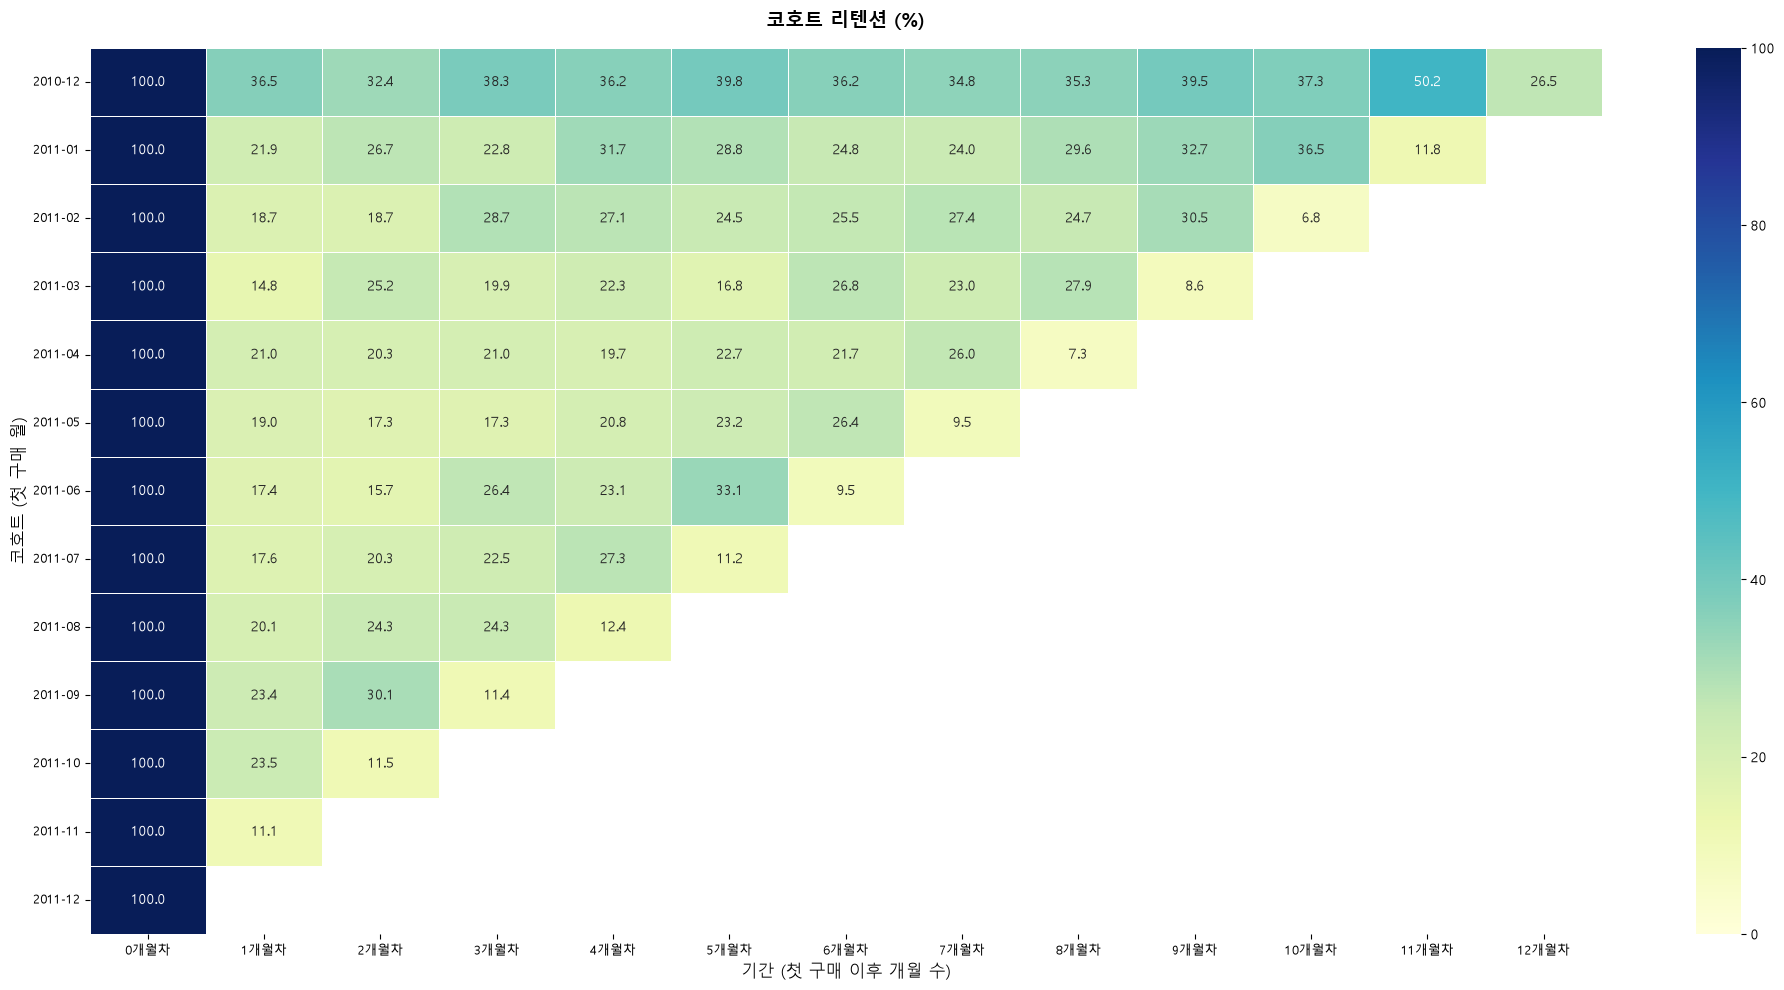

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(20, 10))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax
)

ax.set_title('retention-cohort (%)',
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel('기간 (첫 구매 이후 개월 수)', fontsize=12)
ax.set_ylabel('코호트 (첫 구매 월)', fontsize=12)

ax.set_yticklabels(
    [d.strftime('%Y-%m') for d in retention_matrix.index],
    rotation=0,
    fontsize=9
)

ax.set_xticklabels(
    [f'{int(x)}개월차' for x in retention_matrix.columns],
    rotation=0,
    fontsize=9
)

plt.tight_layout()
plt.savefig('imgs/cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
retention_matrix

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12-01,100.0,36.5,32.4,38.3,36.2,39.8,36.2,34.8,35.3,39.5,37.3,50.2,26.5
2011-01-01,100.0,21.9,26.7,22.8,31.7,28.8,24.8,24.0,29.6,32.7,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.7,27.1,24.5,25.5,27.4,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,14.8,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.0,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.4,15.7,26.4,23.1,33.1,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,17.6,20.3,22.5,27.3,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.1,24.3,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


1. 이탈의 가장 큰 구간은 M1 (첫 달 이후)

첫 구매 이후 한 달 안에 신규 고객의 약 75~85%가 이탈한다.

→ 대부분의 코호트에서 M1에서 리텐션이 15~25% 수준으로 급락한다.



2. 12월(December) 코호트가 가장 충성도가 높음

2010-12 코호트는 이후 기간에서도 30~40% 수준의 높은 리텐션을 유지한다.

→ 다른 코호트(10~25%) 대비 확실히 높은 장기 유지율을 보인다.



3. 계절성 효과 (특히 연말 재방문) 존재

M11~M12 구간에서 일부 코호트의 리텐션이 다시 상승하거나 유지되는 패턴이 있다.

→ 크리스마스 시즌에 고객이 재구매/재방문하는 경향이 강함.



4. M2 이후 리텐션 안정화

M1에서 크게 이탈한 이후, M2~M5 구간에서는 감소 폭이 완만해진다.

→ 2개월까지 유지된 고객은 장기 고객으로 전환될 가능성이 높다.